In [72]:
import sys
from pathlib import Path
sys.path.append(str(Path('../python_code').resolve()))
import os
import re
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import DataLoader
from DataGenerator import HyperspectralTorchDataset
from SpectralSpatialAttentionModel import SpectralSpatialSingleHeatmapAttentionModel, SpectralSpatialMultiHeatmapAttentionModel


# Matplotlib inline for notebooks
%matplotlib inline

In [73]:
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [34]:
image_path = Path("../home/ARO.local/collaboration/sagi-tomer-collab/Normalized_Tomato_Seeds/Infected/Tray_2_row_19_column_3.npy")
model_path = Path("../home/ARO.local/collaboration/sagi-tomer-collab/Normalized_Tomato_Seeds/Models/OptimizedModule_0-319-639-bands-0.941-accuracy.pt")
model_path = Path("../home/ARO.local/collaboration/sagi-tomer-collab/Normalized_Tomato_Seeds/Models/SpectralSpatialMultiHeatmapAttentionModel_0-319-639-bands-0.844-accuracy.pt")
seeds_root = Path("../home/ARO.local/collaboration/sagi-tomer-collab/Normalized_Tomato_Seeds")

In [35]:
# --- Infer Bands and Label ---
model_name = model_path.stem
bands_str = model_name.split("_")[1].split("-bands")[0]
bands = list(map(int, bands_str.split("-")))
label = 0 if "Healthy" in str(image_path) else 1

print(bands, label)

[0, 319, 639] 1


In [36]:
# --- Prepare Image ---
image = np.load(image_path)
height, width = image.shape[:2]
shape = (height, width, len(bands))

In [37]:
dataset = HyperspectralTorchDataset([str(image_path)], [label], bands, shape)
loader = DataLoader(dataset, batch_size=1, shuffle=False)

(91, 110, 3)


In [ ]:
model = SpectralSpatialSingleHeatmapAttentionModel(len(bands))
# model = SpectralSpatialMultiHeatmapAttentionModel(len(bands))

# Load the state dict
state = torch.load(model_path, map_location=device)

# Strip the prefix, if needed (for example, '_orig_mod.')
state = {k.replace("_orig_mod.", ""): v for k, v in state.items()}

# Get current model state_dict
model_state = model.state_dict()

# Update only the matching keys
for key in model_state.keys():
    if key in state and state[key].shape == model_state[key].shape:
        model_state[key] = state[key]  # Copy the matching weights

# Load the state_dict into the model
model.load_state_dict(model_state)

# Now the model is partially loaded with compatible weights
model = torch.compile(model, backend="eager")
model.to(device).eval()


Inference & extract attentions

In [ ]:
with torch.no_grad():
    for x, _ in loader:
        x = x.to(device)
        out = model(x)
        # Unpack outputs
        logits, spec_w, heatmaps, fusion_w = out
        break

# Convert to numpy
spec_w = spec_w.squeeze().cpu().numpy()        # (num_bands,)
fusion_w = fusion_w.squeeze().cpu().numpy()    # (fusion_dims,)
input_bands = x.squeeze().cpu().numpy()        # (num_bands, H, W)
# spat_map from model is (1, 1, H, W) or (1, H, W). Extract 2D map:
sp_map = heatmaps.cpu().numpy()
# Remove batch and channel dims
if sp_map.ndim == 4:
    heatmap = sp_map[0, 0]
elif sp_map.ndim == 3:
    # either (1, H, W) or (bands, H, W)
    heatmap = sp_map.squeeze(0)
else:
    heatmap = sp_map

In [40]:
print(sp_map.shape)
print(spec_w.shape, heatmap.shape, fusion_w.shape)

(1, 1, 91, 110)
(3,) (91, 110) (6,)


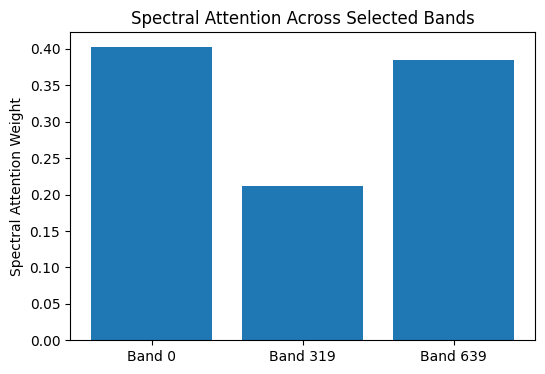

In [41]:
plt.figure(figsize=(6,4))
plt.bar(range(len(spec_w)), spec_w)
plt.xticks(range(len(spec_w)), [f"Band {b}" for b in bands])
plt.ylabel("Spectral Attention Weight")
plt.title("Spectral Attention Across Selected Bands")
plt.show()

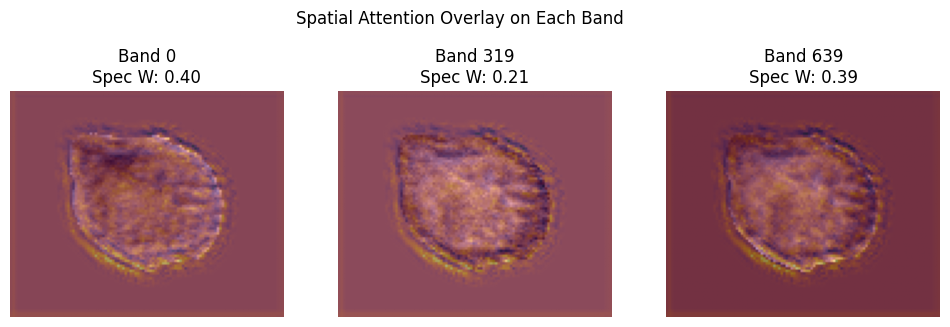

In [42]:
num_bands = len(bands)
fig, axes = plt.subplots(1, num_bands, figsize=(4*num_bands,4))
for i in range(num_bands):
    axes[i].imshow(input_bands[i], cmap='gray')
    axes[i].imshow(heatmap, cmap='inferno', alpha=0.5)
    axes[i].set_title(f"Band {bands[i]}\nSpec W: {spec_w[i]:.2f}")
    axes[i].axis('off')
plt.suptitle("Spatial Attention Overlay on Each Band")
plt.show()

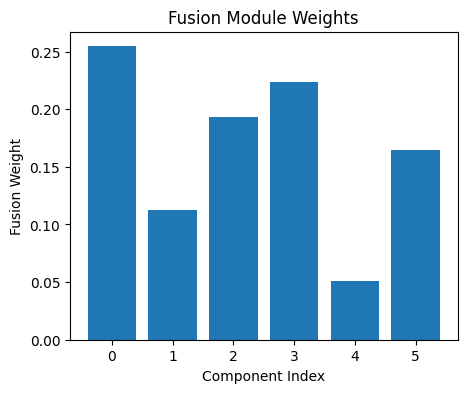

In [43]:
plt.figure(figsize=(5,4))
plt.bar(range(len(fusion_w)), fusion_w)
plt.xlabel("Component Index")
plt.ylabel("Fusion Weight")
plt.title("Fusion Module Weights")
plt.show()

In [44]:
prob = torch.sigmoid(logits).item()
pred = int(prob > 0.5)
print(f"Logits: {logits.item():.4f}, Probability: {prob:.4f}")
print("Predicted:", "Infected" if pred else "Healthy")

Logits: 3.1658, Probability: 0.9595
Predicted: Infected


Band maps shape: (3, 91, 110)
Spectral weights shape: (3,)
Fusion weights shape: (6,)


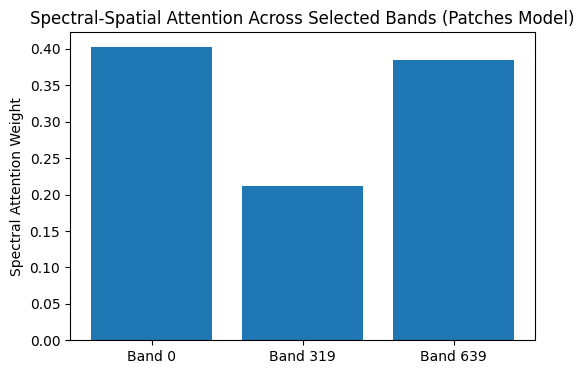

Upsampled band maps shape: (3, 91, 110)


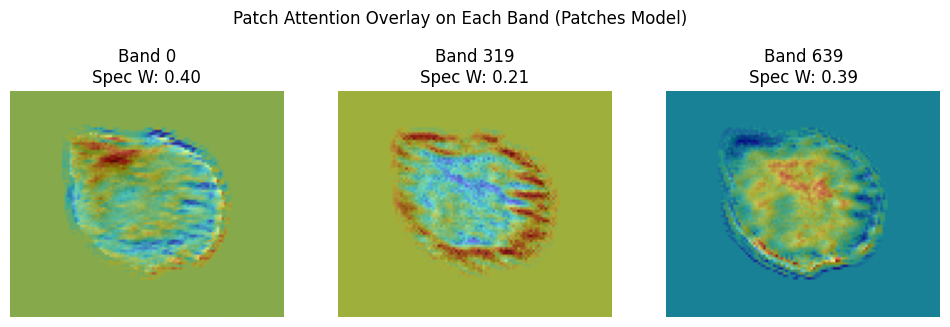

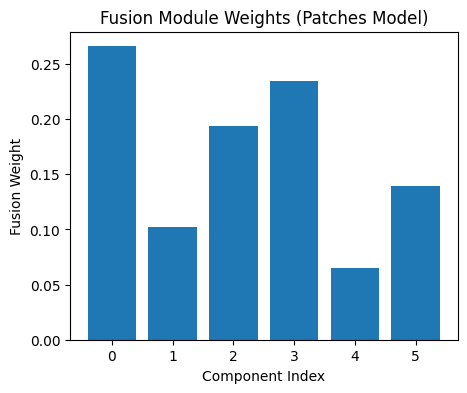

Logits: 3.4799, Probability: 0.9701
Predicted: Infected


In [ ]:
# --- Inference & extract per-band patch attentions ---
with torch.no_grad():
    for x, _ in loader:
        x = x.to(device)
        out = model(x)
        # Unpack outputs
        logits, spec_w, heatmaps, fusion_w = out
        break

# Convert to numpy
spec_w = spec_w.squeeze().cpu().numpy()        # (num_bands,)
fusion_w = fusion_w.squeeze().cpu().numpy()     # (fusion_dims,)
input_bands = x.squeeze().cpu().numpy()         # (num_bands, H, W)

# band_maps: (1, num_bands, h_patches, w_patches)
heatmaps = heatmaps.squeeze(0).cpu().numpy()  # (num_bands, h_patches, w_patches)

print("Band maps shape:", heatmaps.shape)
print("Spectral weights shape:", spec_w.shape)
print("Fusion weights shape:", fusion_w.shape)

# --- Plot Spectral Weights ---
plt.figure(figsize=(6,4))
plt.bar(range(len(spec_w)), spec_w)
plt.xticks(range(len(spec_w)), [f"Band {b}" for b in bands])
plt.ylabel("Spectral Attention Weight")
plt.title("Spectral-Spatial Attention Across Selected Bands (Patches Model)")
plt.show()

# --- Plot Per-Band Patch Attention Maps ---
import torch.nn.functional as F

num_bands = len(bands)
h_patches, w_patches = heatmaps.shape[1:]

# Upsample each patch attention to full image size
# band_maps: (num_bands, h_patches, w_patches)
band_maps_up = F.interpolate(torch.tensor(heatmaps).unsqueeze(0), size=(input_bands.shape[1], input_bands.shape[2]), mode='nearest').squeeze(0).numpy()
print("Upsampled band maps shape:", band_maps_up.shape)

fig, axes = plt.subplots(1, num_bands, figsize=(4*num_bands,4))
for i in range(num_bands):
    axes[i].imshow(input_bands[i], cmap='gray')
    axes[i].imshow(band_maps_up[i], cmap='jet', alpha=0.5)
    axes[i].set_title(f"Band {bands[i]}\nSpec W: {spec_w[i]:.2f}")
    axes[i].axis('off')
plt.suptitle("Patch Attention Overlay on Each Band (Patches Model)")
plt.show()

# --- Plot Fusion Module Weights ---
plt.figure(figsize=(5,4))
plt.bar(range(len(fusion_w)), fusion_w)
plt.xlabel("Component Index")
plt.ylabel("Fusion Weight")
plt.title("Fusion Module Weights (Patches Model)")
plt.show()

# --- Print Prediction ---
prob = torch.sigmoid(logits).item()
pred = int(prob > 0.5)
print(f"Logits: {logits.item():.4f}, Probability: {prob:.4f}")
print("Predicted:", "Infected" if pred else "Healthy")


Using device: cpu
Using model: SpectralSpatialPatchHeatmapAttentionModel_0-63-126-189-252-315-378-441-504-567-630-bands-0.981-accuracy
Bands: [0, 63, 126, 189, 252, 315, 378, 441, 504, 567, 630], Label: 1, Model Type: patch
(90, 110, 11)
Band 0: 0.1107
Band 63: 0.0792
Band 126: 0.0618
Band 189: 0.0618
Band 252: 0.0877
Band 315: 0.1323
Band 378: 0.0729
Band 441: 0.0858
Band 504: 0.1061
Band 567: 0.0823
Band 630: 0.1193


C:\Users\sagig\AppData\Local\Temp\ipykernel_26816\974927666.py:65: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(model_path, map_location=device)


Logits: 6.4657, Probability: 0.9984
Predicted: Infected
Ground truth label: Infected


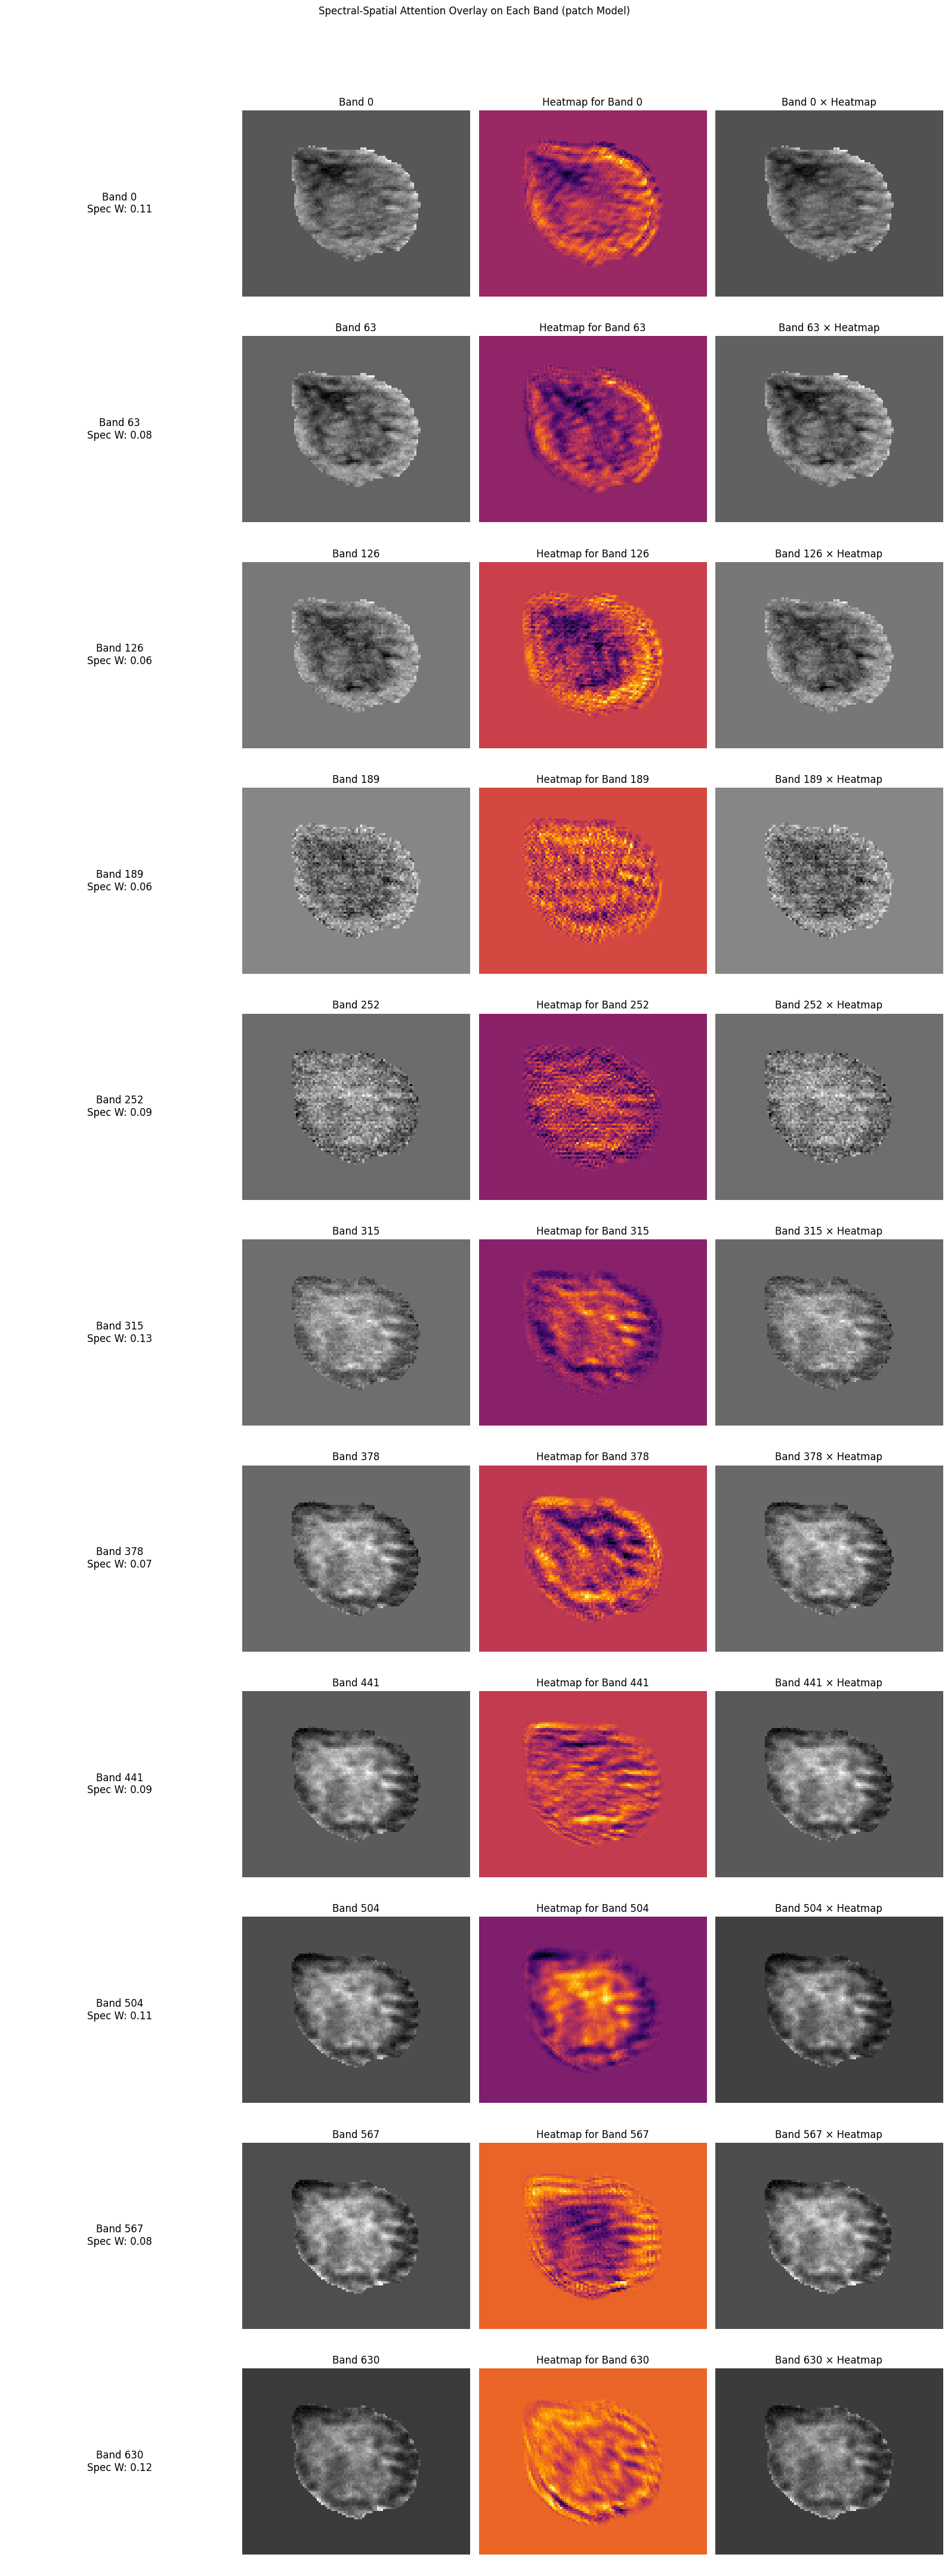

In [98]:

import sys
from pathlib import Path
sys.path.append(str(Path('../python_code').resolve()))
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
import torch.nn.functional as F
from SpectralSpatialAttentionModel import SpectralSpatialSingleHeatmapAttentionModel, SpectralSpatialMultiHeatmapAttentionModel, SpectralSpatialPatchHeatmapAttentionModel
from DataGenerator import HyperspectralTorchDataset

# Set up device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Paths (customize these as needed)
image_path = Path("../home/ARO.local/collaboration/sagi-tomer-collab/Normalized_Tomato_Seeds/Infected/Tray_2_row_19_column_3.npy")
model_path = Path("../home/ARO.local/collaboration/sagi-tomer-collab/Normalized_Tomato_Seeds/Models/SpectralSpatialMultiHeatmapAttentionModel_0-63-126-189-252-315-378-441-504-567-630-bands-0.963-accuracy.pt")
model_path = Path("../home/ARO.local/collaboration/sagi-tomer-collab/Normalized_Tomato_Seeds/Models/SpectralSpatialPatchHeatmapAttentionModel_0-63-126-189-252-315-378-441-504-567-630-bands-0.981-accuracy.pt")
seeds_root = Path("../home/ARO.local/collaboration/sagi-tomer-collab/Normalized_Tomato_Seeds")

# --- Extract Model Info --- #
model_name = model_path.stem
bands_str = model_name.split("_")[1].split("-bands")[0]
bands = list(map(int, bands_str.split("-")))
label = 0 if "Healthy" in str(image_path) else 1

# Detect model type from the model name
if "MultiHeatmap" in model_name:
    model_type = "multi"
elif "SingleHeatmap" in model_name:
    model_type = "single"
elif "Patch" in model_name:
    model_type = "patch"
else:
    raise ValueError(f"Unknown model type in the filename: {model_name}")

print(f"Using model: {model_name}")
print(f"Bands: {bands}, Label: {label}, Model Type: {model_type}")

# --- Prepare Image Data --- #
image = np.load(image_path)
height, width = image.shape[:2]
shape = (height, width, len(bands))

# --- Load Model --- #
if model_type == "multi":
    model = SpectralSpatialMultiHeatmapAttentionModel(len(bands))
elif model_type == "single":
    model = SpectralSpatialSingleHeatmapAttentionModel(len(bands))
elif model_type == "patch":
    model = SpectralSpatialPatchHeatmapAttentionModel(len(bands))
    patch_size = 10  # model.band_spat_attn.patch_size
    new_height = (height // patch_size) * patch_size
    new_width = (width // patch_size) * patch_size
    image = image[:new_height, :new_width, :]
    shape = (new_height, new_width, len(bands))
else:
    raise ValueError(f"Model type '{model_type}' not recognized.")

dataset = HyperspectralTorchDataset([str(image_path)], [label], bands, shape)
loader = DataLoader(dataset, batch_size=1, shuffle=False)

# Load the state dict
state = torch.load(model_path, map_location=device)
state = {k.replace("_orig_mod.", ""): v for k, v in state.items()}

# Get current model state_dict
model_state = model.state_dict()

# Update only the matching keys
for key in model_state.keys():
    if key in state and state[key].shape == model_state[key].shape:
        model_state[key] = state[key]

model.load_state_dict(model_state)
model = torch.compile(model, backend="eager")
model.to(device).eval()

# --- Inference & Extract Attention --- #
with torch.no_grad():
    for x, _ in loader:
        x = x.to(device)
        out = model(x)
        if model_type == "patch":
            logits, spec_w, heatmaps, fusion_w = out
            heatmaps = heatmaps[:, :, :new_height, :new_width]
        else:
            logits, spec_w, heatmaps, fusion_w = out
        break

# Convert to numpy for visualization
spec_w = spec_w.squeeze().cpu().numpy()  # Spectral weights
heatmaps = heatmaps.squeeze(0).cpu().numpy()
fusion_w = fusion_w.squeeze().cpu().numpy()  # Fusion weights
input_bands = x.squeeze().cpu().numpy()  # Original bands
if model_type == "patch":
    input_bands = np.transpose(input_bands, (1, 2, 0))
    input_bands = input_bands[:new_height, :new_width, :]

print("\n".join([f"Band {band}: {score:.4f}" for band, score in zip(bands, spec_w)]))

# --- Visualize Results --- #
num_bands = len(bands)
fig, axes = plt.subplots(num_bands, 4, figsize=(16, 4 * num_bands))

for i in range(num_bands):
    # Display Band Info
    axes[i, 0].text(0.5, 0.5, f"Band {bands[i]}\nSpec W: {spec_w[i]:.2f}", ha='center', va='center', fontsize=12)
    axes[i, 0].axis('off')

    input_band = input_bands[:,:,i] if model_type == "patch" else input_bands[i]
    
    # Original Band
    axes[i, 1].imshow(input_band, cmap='gray')
    axes[i, 1].set_title(f"Band {bands[i]}")
    axes[i, 1].axis('off')
    
    axes[i, 2].imshow(heatmaps[i], cmap='inferno')
    axes[i, 2].set_title(f"Heatmap for Band {bands[i]}")
    axes[i, 2].axis('off')

    # Band × Heatmap
    combined_image = input_band * heatmaps[i]
    axes[i, 3].imshow(combined_image, cmap='gray')
    axes[i, 3].set_title(f"Band {bands[i]} × Heatmap")
    axes[i, 3].axis('off')

    # Fusion Image (use fusion weight for patch-based models)
    # if model_type == "patch":
    #     fusion_heatmap = fusion_w[i]
    #     axes[i, 4].imshow(fusion_heatmap, cmap='inferno', alpha=0.5)
    #     axes[i, 4].set_title(f"Fusion Heatmap for Band {bands[i]}")
    #     axes[i, 4].axis('off')
    # else:
    #     axes[i, 4].axis('off')  # Skip if not patch model

# --- Model Prediction & Comparison --- #
prob = torch.sigmoid(logits).item()
pred = int(prob > 0.5)
print(f"Logits: {logits.item():.4f}, Probability: {prob:.4f}")
print(f"Predicted: {'Infected' if pred else 'Healthy'}")
print(f"Ground truth label: {'Infected' if label else 'Healthy'}")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.suptitle(f"Spectral-Spatial Attention Overlay on Each Band ({model_type} Model)")
plt.show()
